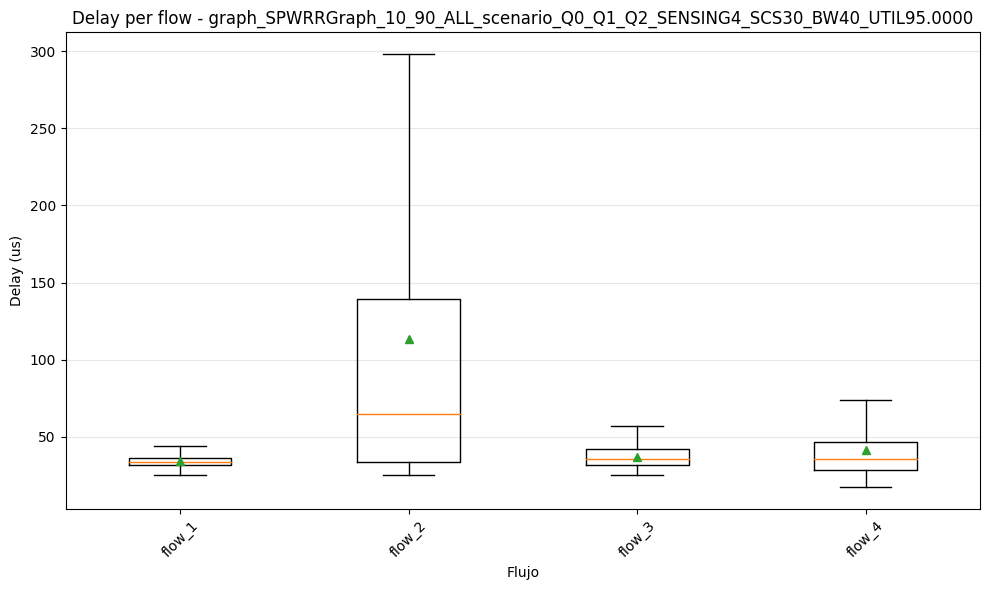

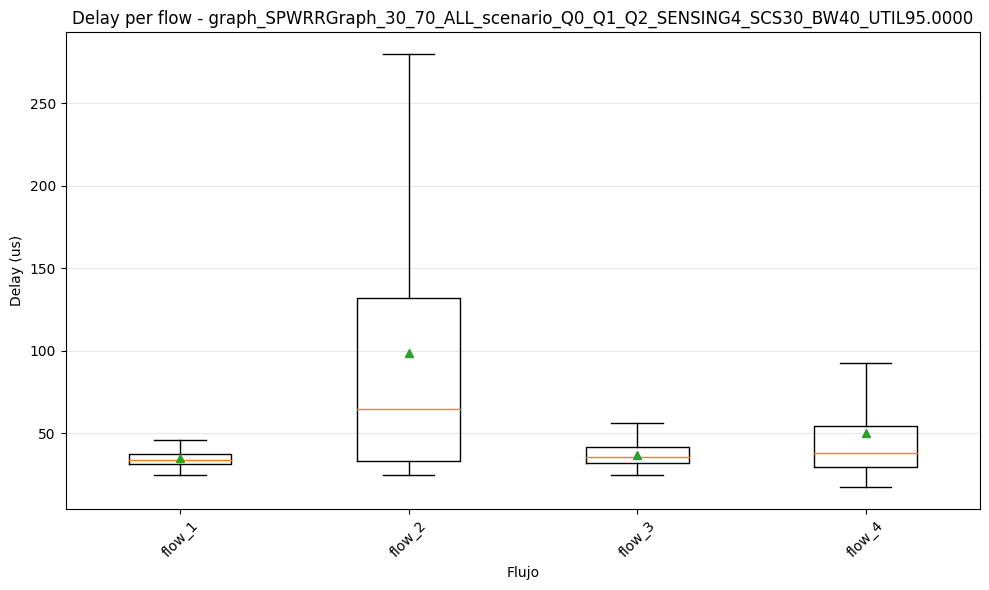

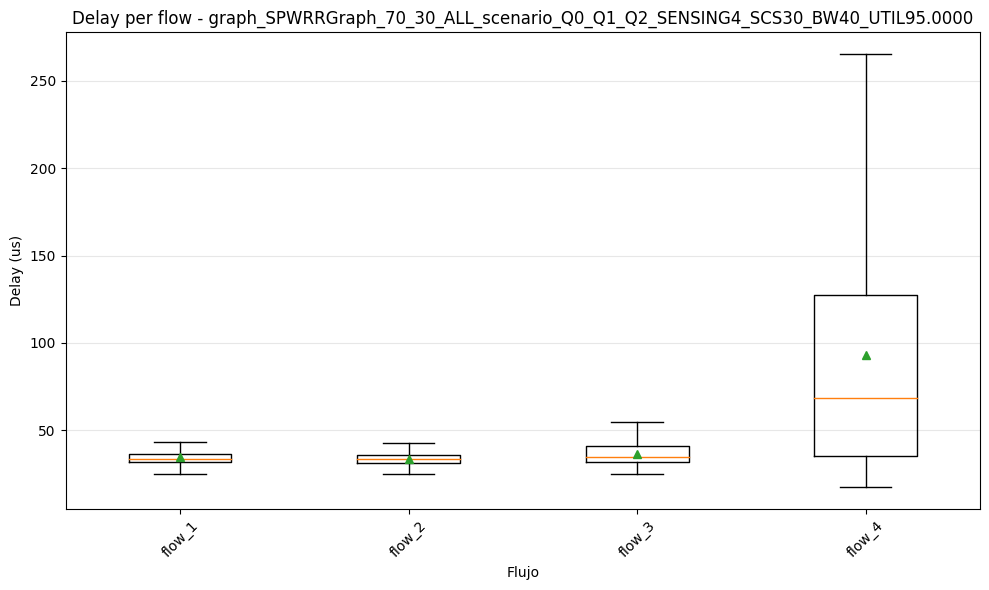

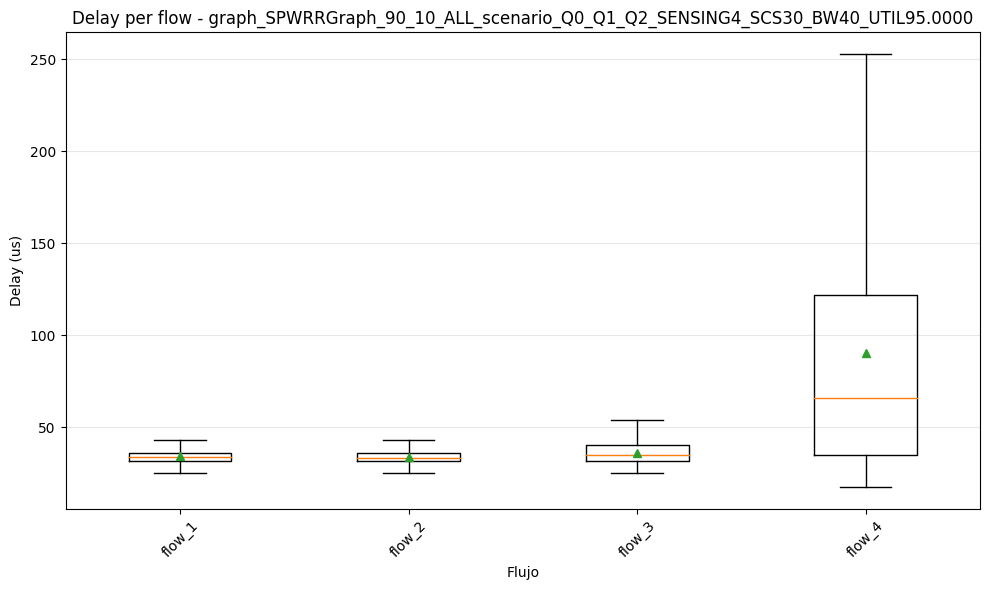

In [20]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# Ruta al dataset (ajústala si cambiaste la estructura)
dataset_root = Path("./generate-datasetsHQoS/datasets/oran-hqos_test_2s/train/").resolve()  
# dataset_root = Path("./ns3-automated-output").resolve()  
# dataset_root = Path("./generate-datasets/datasets/o-ran-full-v1/train/").resolve()  
# Conversión de tiempo: en tus ficheros parece estar en femtosegundos
TIME_SCALE = 1e3  # ns -> s



# scenario_dirs = sorted([p for p in dataset_root.iterdir() if p.is_dir() and p.name.startswith("graph_SPWRRGraph_5_5_ALL_scenario_Q0_Q1_Q2_")])
# scenario_dirs = dataset_root.glob("*")  # Alternativa con glob

UTIL_THRESHOLD = 90  # Umbral que definiste

# 1. Obtener directorios que coincidan con el patrón base
all_scenarios = sorted([p for p in dataset_root.iterdir() if p.is_dir() and p.name.startswith("graph_")])
scenario_dirs = []

for scen in all_scenarios:
    # 2. Usar regex para capturar el valor numérico después de "_UTIL"
    match = re.search(r"_UTIL(\d+(?:\.\d+)?)$", scen.name)
    if match:
        util_value = float(match.group(1))
        # 3. Filtrar solo los que superan el umbral
        if util_value > UTIL_THRESHOLD:
            scenario_dirs.append(scen)
if not scenario_dirs:
    print("No se encontraron escenarios en:", dataset_root)
   
    # Detectar IDs de flujo por nombre de fichero rxfileflowX.txt
    rx_files = sorted(dataset_root.glob("rxfileflow*.txt"))
    flow_ids = []
    for f in rx_files:
        m = re.search(r"rxfileflow(\d+)\.txt$", f.name)
        if m:
            print(f"Encontrado flujo ID: {m.group(1)} en archivo {f.name}")
            flow_ids.append(int(m.group(1)))
    flow_ids = sorted(set(flow_ids))

    labels = []
    data = []

    for fid in flow_ids:
        tx_path = dataset_root / f"txfileflow{fid}.txt"
        rx_path = dataset_root / f"rxfileflow{fid}.txt"

        if not tx_path.exists() or not rx_path.exists():
            continue

        # Leer TX: pkt_id -> tx_time
        tx_times = {}
        with tx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    tx_t = float(parts[1])
                    tx_times[pkt_id] = tx_t

        # Leer RX y calcular delay por paquete
        delays = []
        with rx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    rx_t = float(parts[1])
                    if pkt_id in tx_times:
                        d = (rx_t - tx_times[pkt_id]) / TIME_SCALE
                        if d >= 0:
                            delays.append(d)

        if len(delays) > 0:
            labels.append(f"flow_{fid}")
            data.append(np.array(delays, dtype=float))

    if len(data) == 0:
        print(f"{dataset_root.name}: sin delays válidos para pintar")
       

    # Tamaño dinámico según nº de flujos
    fig_w = max(10, 1.2 * len(data))
    plt.figure(figsize=(fig_w, 6))
    plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
    plt.title(f"Delay per flow - {dataset_root.name}")
    plt.xlabel("Flujo")
    plt.ylabel("Delay (us)")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    for scen_dir in scenario_dirs:
        # Detectar IDs de flujo por nombre de fichero rxfileflowX.txt
        rx_files = sorted(scen_dir.glob("rxfileflow*.txt"))
        flow_ids = []
        for f in rx_files:
            m = re.search(r"rxfileflow(\d+)\.txt$", f.name)
            if m:
                flow_ids.append(int(m.group(1)))
        flow_ids = sorted(set(flow_ids))

        labels = []
        data = []

        for fid in flow_ids:
            tx_path = scen_dir / f"txfileflow{fid}.txt"
            rx_path = scen_dir / f"rxfileflow{fid}.txt"

            if not tx_path.exists() or not rx_path.exists():
                continue

            # Leer TX: pkt_id -> tx_time
            tx_times = {}
            with tx_path.open("r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        pkt_id = int(parts[0])
                        tx_t = float(parts[1])
                        tx_times[pkt_id] = tx_t

            # Leer RX y calcular delay por paquete
            delays = []
            with rx_path.open("r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) >= 2:
                        pkt_id = int(parts[0])
                        rx_t = float(parts[1])
                        if pkt_id in tx_times:
                            d = (rx_t - tx_times[pkt_id]) / TIME_SCALE
                            if d >= 0:
                                delays.append(d)

            if len(delays) > 0:
                labels.append(f"flow_{fid}")
                data.append(np.array(delays, dtype=float))

        if len(data) == 0:
            print(f"{scen_dir.name}: sin delays válidos para pintar")
            continue

        # Tamaño dinámico según nº de flujos
        fig_w = max(10, 1.2 * len(data))
        plt.figure(figsize=(fig_w, 6))
        plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
        plt.title(f"Delay per flow - {scen_dir.name}")
        plt.xlabel("Flujo")
        plt.ylabel("Delay (us)")
        plt.grid(axis="y", alpha=0.3)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()



graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.560 us
graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 113.177 us
graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.841 us


graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 41.482 us

>>> graph_SPWRRGraph_10_90_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 53.584 us



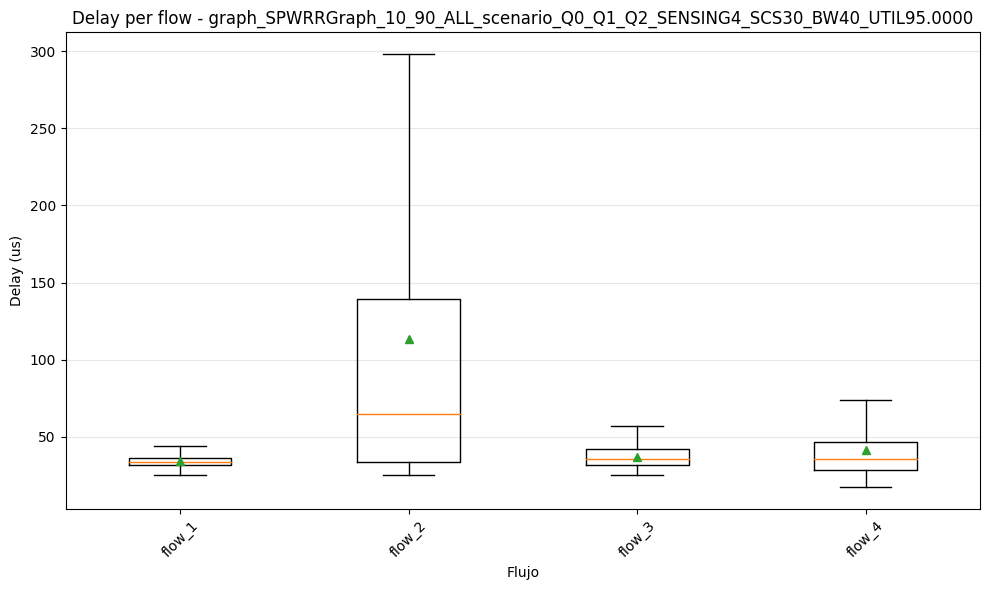

graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.768 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 98.703 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.687 us
graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 50.386 us

>>> graph_SPWRRGraph_30_70_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 56.709 us



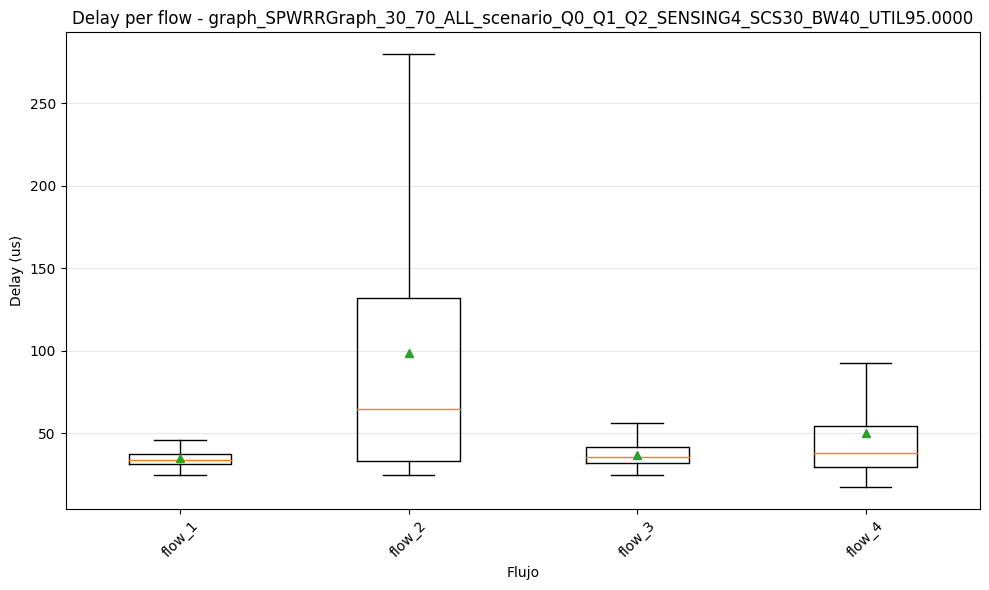

graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.309 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 50.301 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.254 us
graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 80.341 us

>>> graph_SPWRRGraph_50_50_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 67.223 us



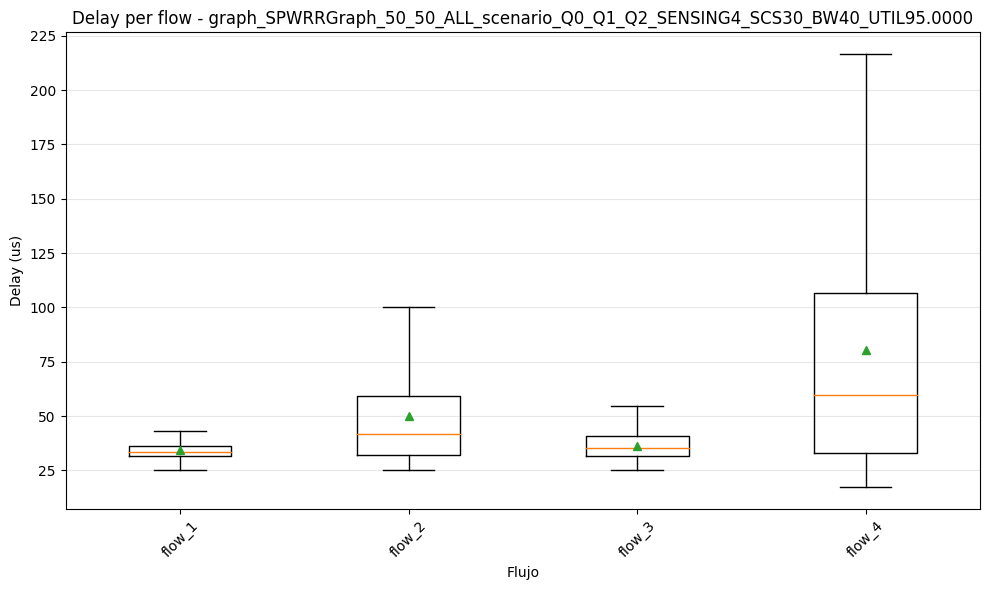

graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.199 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 33.938 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.003 us
graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 90.501 us

>>> graph_SPWRRGraph_70_30_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 70.789 us



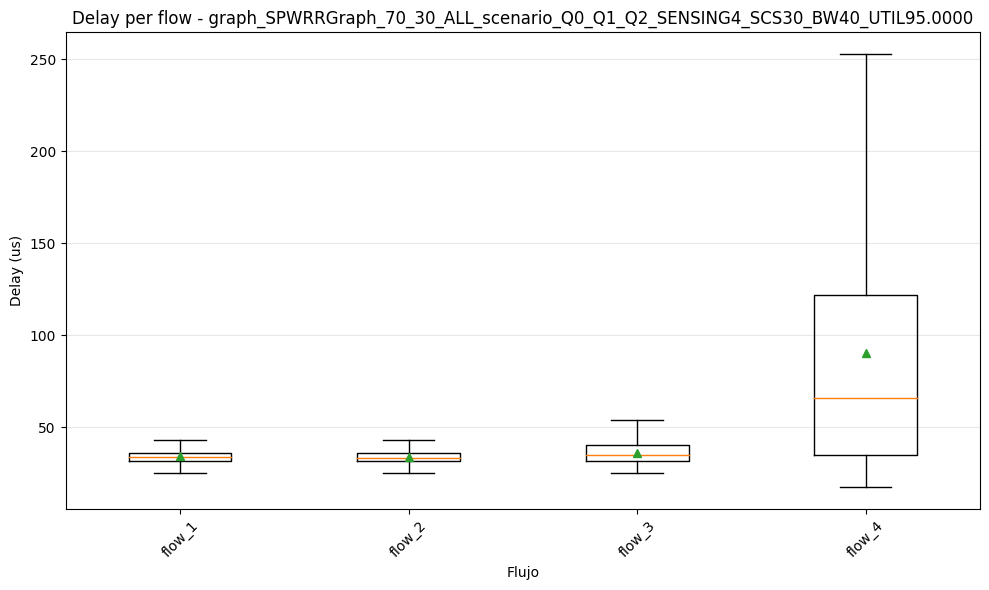

graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_1 -> mean delay: 34.199 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_2 -> mean delay: 33.938 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_3 -> mean delay: 36.003 us
graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 | flow_4 -> mean delay: 90.501 us

>>> graph_SPWRRGraph_90_10_ALL_scenario_Q0_Q1_Q2_SENSING4_SCS30_BW40_UTIL95.0000 -> mean TOTAL delay: 70.789 us



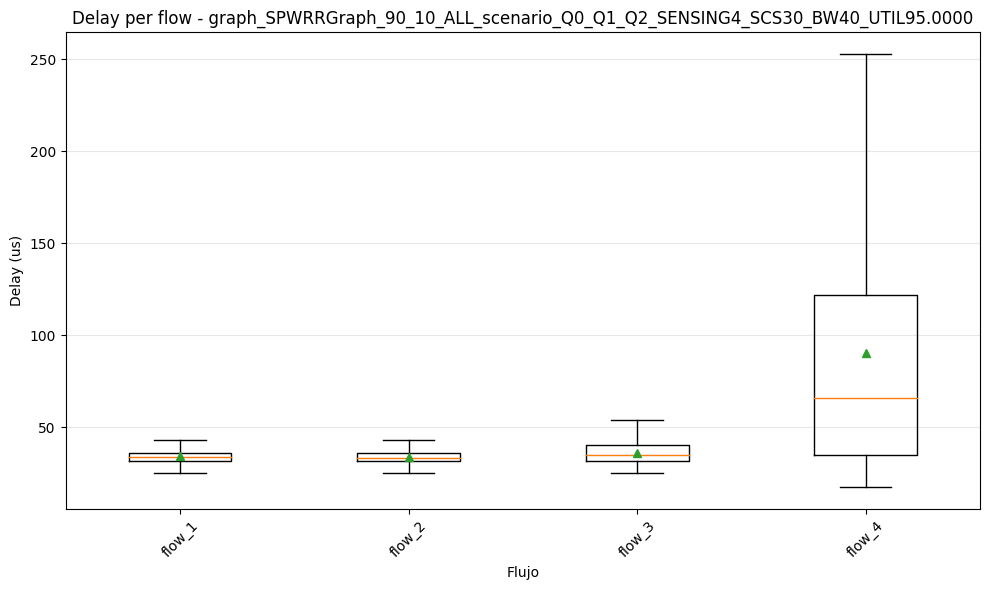

In [23]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt

# Ruta al dataset (ajústala si cambiaste la estructura)
dataset_root = Path("./generate-datasetsHQoS/datasets/oran-hqos_test_2s/train/").resolve()

# Conversión de tiempo
TIME_SCALE = 1e3  # ns -> us

UTIL_THRESHOLD = 90  # Umbral

# 1. Obtener escenarios con UTIL > threshold
all_scenarios = sorted([p for p in dataset_root.iterdir() if p.is_dir() and p.name.startswith("graph_")])
scenario_dirs = []

for scen in all_scenarios:
    match = re.search(r"_UTIL(\d+(?:\.\d+)?)$", scen.name)
    if match:
        util_value = float(match.group(1))
        if util_value > UTIL_THRESHOLD:
            scenario_dirs.append(scen)

# =========================================================
# FUNCIÓN reutilizable para procesar un directorio
# =========================================================
def process_directory(base_dir):
    rx_files = sorted(base_dir.glob("rxfileflow*.txt"))
    flow_ids = []

    for f in rx_files:
        m = re.search(r"rxfileflow(\d+)\.txt$", f.name)
        if m:
            flow_ids.append(int(m.group(1)))

    flow_ids = sorted(set(flow_ids))

    labels = []
    data = []
    means = {}

    for fid in flow_ids:
        tx_path = base_dir / f"txfileflow{fid}.txt"
        rx_path = base_dir / f"rxfileflow{fid}.txt"

        if not tx_path.exists() or not rx_path.exists():
            continue

        # Leer TX
        tx_times = {}
        with tx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    tx_times[pkt_id] = float(parts[1])

        # Leer RX y calcular delays
        delays = []
        with rx_path.open("r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 2:
                    pkt_id = int(parts[0])
                    rx_t = float(parts[1])

                    if pkt_id in tx_times:
                        d = (rx_t - tx_times[pkt_id]) / TIME_SCALE
                        if d >= 0:
                            delays.append(d)

        if len(delays) > 0:
            delays_array = np.array(delays, dtype=float)
            mean_delay = np.mean(delays_array)

            print(f"{base_dir.name} | flow_{fid} -> mean delay: {mean_delay:.3f} us")

            means[f"flow_{fid}"] = mean_delay
            labels.append(f"flow_{fid}")
            data.append(delays_array)

    if len(data) == 0:
        print(f"{base_dir.name}: sin delays válidos para pintar")
        return

    # Media total del escenario
    all_delays = np.concatenate(data)
    total_mean = np.mean(all_delays)

    print(f"\n>>> {base_dir.name} -> mean TOTAL delay: {total_mean:.3f} us\n")

    # Boxplot
    fig_w = max(10, 1.2 * len(data))
    plt.figure(figsize=(fig_w, 6))
    plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
    plt.title(f"Delay per flow - {base_dir.name}")
    plt.xlabel("Flujo")
    plt.ylabel("Delay (us)")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================

if not scenario_dirs:
    print("No se encontraron escenarios filtrados. Procesando dataset_root directamente...\n")
    process_directory(dataset_root)
else:
    for scen_dir in scenario_dirs:
        process_directory(scen_dir)

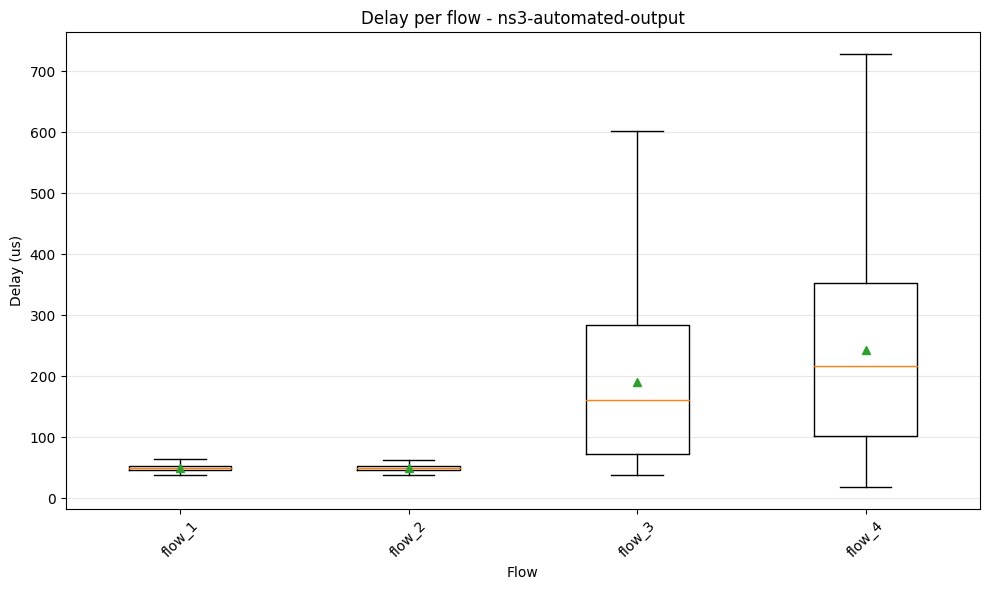


✔ Statistics exported to delay_statistics.csv
               scenario    flow        mean         std     min      max  \
0  ns3-automated-output  flow_1   50.112047    5.040173  38.478   73.306   
1  ns3-automated-output  flow_2   49.768991    4.634347  38.478   73.893   
2  ns3-automated-output  flow_3  189.892891  134.612812  38.478  850.925   
3  ns3-automated-output  flow_4  242.758419  161.952579  17.604  946.116   

       p50       p95        p99       q1       q3      iqr  lower_whisker  \
0   49.314   58.4208   64.46088   46.634   53.577    6.943         38.478   
1   49.143   56.7990   62.01376   46.501   53.272    6.771         38.478   
2  160.355  434.3742  575.85604   72.200  284.857  212.657         38.478   
3  217.518  542.4080  688.10400  102.321  353.172  250.851         17.604   

   upper_whisker  count  
0         63.929   3565  
1         63.421   7813  
2        602.520  12085  
3        728.660  43281  


In [197]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# CONFIG
# =========================
dataset_root = Path("./ns3-automated-output").resolve()
TIME_SCALE = 1e3  # ns -> us (ajusta si necesario)


# =========================
# DELAY EXTRACTION
# =========================
def extract_flow_delays(base_path, flow_id, time_scale=1e3):
    tx_path = base_path / f"txfileflow{flow_id}.txt"
    rx_path = base_path / f"rxfileflow{flow_id}.txt"

    if not tx_path.exists() or not rx_path.exists():
        return None

    tx_times = {}

    # TX parsing
    with tx_path.open("r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                pkt_id = int(parts[0])
                tx_times[pkt_id] = float(parts[1])

    # RX parsing
    delays = []
    with rx_path.open("r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 2:
                pkt_id = int(parts[0])
                rx_t = float(parts[1])

                if pkt_id in tx_times:
                    d = (rx_t - tx_times[pkt_id]) / time_scale
                    if d >= 0:
                        delays.append(d)

    if len(delays) == 0:
        return None

    return np.array(delays, dtype=float)


# =========================
# SCENARIO PROCESSING
# =========================
def process_scenario(scen_dir, time_scale=1e3):
    rx_files = scen_dir.glob("rxfileflow*.txt")

    flow_ids = []
    for f in rx_files:
        m = re.search(r"rxfileflow(\d+)\.txt$", f.name)
        if m:
            flow_ids.append(int(m.group(1)))

    flow_ids = sorted(set(flow_ids))

    labels, data = [], []

    for fid in flow_ids:
        delays = extract_flow_delays(scen_dir, fid, time_scale)
        if delays is not None:
            labels.append(f"flow_{fid}")
            data.append(delays)

    return labels, data


# =========================
# STATISTICS
# =========================
def compute_stats(arr):
    arr = np.array(arr)

    q1 = np.percentile(arr, 25)
    median = np.percentile(arr, 50)
    q3 = np.percentile(arr, 75)

    iqr = q3 - q1
    lower_whisker = np.min(arr[arr >= q1 - 1.5 * iqr]) if len(arr) > 0 else np.nan
    upper_whisker = np.max(arr[arr <= q3 + 1.5 * iqr]) if len(arr) > 0 else np.nan

    return {
        "mean": np.mean(arr),
        "std": np.std(arr),
        "min": np.min(arr),
        "max": np.max(arr),
        "p50": median,
        "p95": np.percentile(arr, 95),
        "p99": np.percentile(arr, 99),
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_whisker": lower_whisker,
        "upper_whisker": upper_whisker,
        "count": len(arr)
    }


# =========================
# PLOTTING
# =========================
def plot_box(labels, data, title):
    if len(data) == 0:
        print(f"[WARN] {title}: sin datos")
        return

    fig_w = max(10, 1.2 * len(data))

    plt.figure(figsize=(fig_w, 6))
    plt.boxplot(data, labels=labels, showfliers=False, showmeans=True)
    plt.title(title)
    plt.xlabel("Flow")
    plt.ylabel("Delay (us)")
    plt.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


# =========================
# MAIN EXECUTION
# =========================
scenario_dirs = sorted([
    p for p in dataset_root.iterdir()
    if p.is_dir() and p.name.startswith("graph_")
])

rows = []

# CASE 1: no scenarios
if not scenario_dirs:
    labels, data = process_scenario(dataset_root)

    plot_box(labels, data, f"Delay per flow - {dataset_root.name}")

    for label, arr in zip(labels, data):
        stats = compute_stats(arr)
        rows.append({"scenario": dataset_root.name, "flow": label, **stats})

# CASE 2: multiple scenarios
else:
    for scen_dir in scenario_dirs:
        labels, data = process_scenario(scen_dir)

        plot_box(labels, data, f"Delay per flow - {scen_dir.name}")

        for label, arr in zip(labels, data):
            stats = compute_stats(arr)
            rows.append({"scenario": scen_dir.name, "flow": label, **stats})


# =========================
# EXPORT RESULTS
# =========================
df = pd.DataFrame(rows)
df.to_csv("delay_statistics.csv", index=False)

print("\n✔ Statistics exported to delay_statistics.csv")
print(df.head())

In [ ]:
print((19225600 + 64886399 + 42055999 + 76705)*8 / 0.95)


1262447030.0
